# This project is about Credit Card churn predition. Where a simple neural network is trained for analysis purpose.

Dataset : https://www.kaggle.com/code/rjmanoj/deploy-churn-prediction-model

# Customer Churn Prediction using Artificial Neural Network (ANN)

- Goal: Predict whether a bank customer will leave (churn) or stay, using a simple neural network built with Keras/TensorFlow.

- Dataset: Churn_Modelling.csv — 10,000 bank customers with features like credit score, geography, gender, age, balance, etc. Target column: Exited (1 = left the bank, 0 = stayed).

What this notebook does, step by step:

1) Load & explore the data — check shape, missing values, duplicates, and class balance.
2) Clean up columns — drop unhelpful columns (RowNumber, CustomerId, Surname).
3) Encode categorical data — convert Geography and Gender into numeric columns (one-hot encoding), since ML models can't read text.
4) Split & scale — split data into train/test sets, then scale all features so the neural network trains properly.
5) Build the ANN — a simple feedforward network with 2 hidden layers (ReLU activation) and 1 output layer (sigmoid, for churn probability).
6) Compile & train — using binary cross-entropy loss and the Adam optimizer, trained for 100 epochs with a validation split to monitor overfitting.
7) Predict & evaluate — convert output probabilities into 0/1 predictions using a 0.5 threshold, then check accuracy on the test set.

**Note** : This hands-on exercise to learn keras workflow 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("c:/Desktop/Desktop/Microsoft_AI_Engineering/deep_learning/dataset/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None


In [7]:
# check for duplicate

df.duplicated().sum()

np.int64(0)

In [8]:
# Get the value counts of Customers who stayed vs exited
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
# Get the value count of each geographic region
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [11]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


- After this step usually is to perform EDA, figuring out which which columns matter and which don't
- But skipping the part as the end goal is to learn how to build a neural network using keras and tensors


In [12]:
#  1 hot encode the categorical columns -- as model don't understand what strings is..so convert to readable form

df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype=int, drop_first=True)   # drop_first - removes the first category from the encoded columns to prevent redundancy

In [12]:
# Now all the columns are numerical and ready for model training

# While Building a neural network, as the values are high/low use Scaling always

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [14]:
# Perform Scaling - -Each row is scaled 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit+transform only on train
X_test_scaled = scaler.transform(X_test)

In [15]:
# After Scaling 

import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential()    # object of model

# Before -- less layers
# model.add(Dense(3, activation='sigmoid', input_dim=11))  #  3 Perceptron/nodes -- Dense(creates a layer).. total inputs are 11 cols
# model.add(Dense(1,activation='sigmoid'))        # output layer

model.add(Dense(11, activation='relu', input_dim=11))  #  3 Perceptron/nodes -- Dense(creates a layer).. total inputs are 11 cols

# add 1 more layer
model.add(Dense(11,activation='relu'))        # another layer of 1 nodes/perceptron
model.add(Dense(1,activation='sigmoid'))  

c:\Desktop\Desktop\Microsoft_AI_Engineering\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

# Less layers
# Layer 1 params: (11 inputs × 3 neurons) + 3 biases = 36
# Layer 2 params: (3 inputs × 1 neuron) + 1 bias = 4
# Total: 40 trainable parameters


# more layers

# Layer      Computation	                            Params
# Hidden 1	(11 inputs × 11 neurons) + 11 biases	132
# Hidden 2	(11 inputs × 11 neurons) + 11 biases	132
# Output	(11 inputs × 1 neuron) + 1 bias	        12
# Total		                                        276

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Below is the initial arch of ANN for churn prediction with just 1 hidden layer 

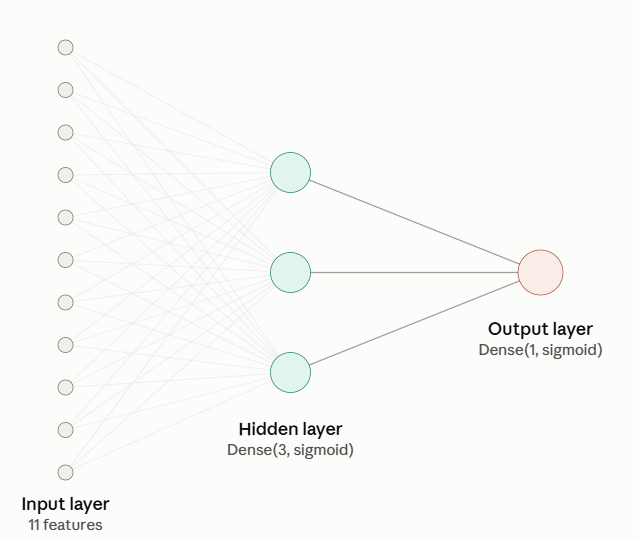

In [ ]:
# Below is the Arch when more layers are added

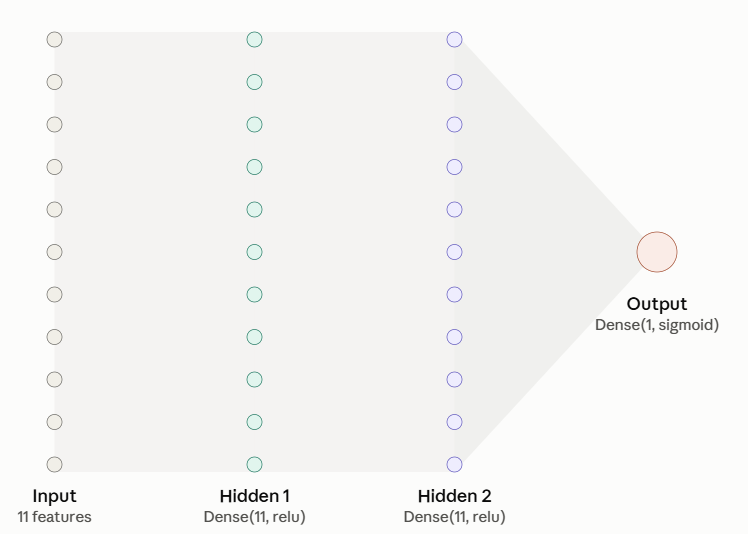

In [29]:
# Now we compile the Model -- In compilation stage we have to mention which loos_function and optimizer to use for gradient descent

model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=["accuracy"])


In [30]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)  # fit the model + tell how many passes we want on the data(epoch)  # intial epoch was 10

# Analysiz# this is the stage where we train the neural network

# validation_set - it splits the X_train_scaled data to 80-20...where again 80% will be trained and simulateneously the rest 20% it will test on that data..and share the accuracy at the same time


# End goal - val_loss should be less and val_accuracy should be high with less overfitting

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8662 - loss: 0.3225 - val_accuracy: 0.8481 - val_loss: 0.3535
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8662 - loss: 0.3218 - val_accuracy: 0.8450 - val_loss: 0.3571
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8673 - loss: 0.3216 - val_accuracy: 0.8462 - val_loss: 0.3530
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3212 - val_accuracy: 0.8438 - val_loss: 0.3540
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8675 - loss: 0.3211 - val_accuracy: 0.8450 - val_loss: 0.3546
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8656 - loss: 0.3218 - val_accuracy: 0.8456 - val_loss: 0.3535
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3213 - val_accuracy: 0.8450 - val_loss: 0.3546
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8681 - loss: 0.3209 - val_acc

In [21]:
# Analysis from the above epoch. At each stage the loss is decreasing

In [31]:
# we can check where the weights and bias of model are stored

model.layers[0].get_weights()   # go to the 0th layer and check the weights of inputs and bias    # 11 weights * 11 bias + 11 bias

[array([[-2.56739527e-01,  4.53123823e-02, -5.27607381e-01,
          6.19219005e-01,  2.49840200e-01, -2.04432175e-01,
          1.03329018e-01,  5.30840456e-01,  3.27012002e-01,
          6.18797541e-02, -2.70258814e-01],
        [ 1.71468541e-01,  2.95898408e-01,  3.77725437e-02,
          1.13132581e-01, -1.78372949e-01, -3.00140291e-01,
         -4.62182127e-02,  7.11135983e-01,  9.72853079e-02,
         -7.92509377e-01,  1.05302644e+00],
        [ 9.98574346e-02, -7.29938745e-02,  3.37001175e-01,
         -3.40557873e-01, -5.42136952e-02,  4.44825292e-01,
         -3.94431204e-02,  1.25832617e-01,  2.94690758e-01,
         -1.74071476e-01, -2.61199534e-01],
        [-1.30475521e-01,  1.07031338e-01, -1.01658440e+00,
         -3.06070536e-01,  6.76910639e-01, -8.77277553e-03,
         -9.67940912e-02, -3.31981219e-02, -9.39241111e-01,
          1.61388695e-01,  3.91340367e-02],
        [ 1.01941121e+00,  6.74080074e-01,  5.50404429e-01,
          1.29902717e-02,  9.66568530e-01,  

In [32]:
# Similarly go to the 1st layer and check

model.layers[1].get_weights()  # 11 weights * 11 bias + 11 bias

[array([[ 0.99693894,  0.05981398, -0.17361057,  0.8005179 ,  0.14336394,
         -0.27481914,  0.7114993 , -0.28629318, -0.7869981 , -0.3285016 ,
          0.20825222],
        [ 0.09121956,  0.09545235,  0.15376006,  0.5135201 , -0.0076519 ,
          0.20850423,  0.7646995 ,  0.41790316, -0.37305075,  0.217231  ,
         -0.81651807],
        [-0.07049444,  0.07449888, -0.6775653 , -0.0083769 ,  0.6891946 ,
          0.7585417 ,  0.29767674,  0.10474458,  0.23312281,  0.4211781 ,
          0.39927375],
        [ 0.2964076 ,  0.53799593, -0.8421512 , -0.41720808,  0.4599022 ,
          0.4650063 , -0.23538889, -0.16829318,  0.2642233 ,  0.21083812,
          0.1816271 ],
        [ 0.791151  ,  0.6053703 ,  0.4486217 ,  0.1142574 , -0.21491133,
         -0.2634779 ,  0.869192  , -0.50996065, -0.6834146 , -0.08661485,
          0.7439175 ],
        [-0.16172746, -1.6341237 ,  0.06347192, -0.06986205,  0.23826511,
         -0.42384502, -0.5488305 , -0.15270463, -0.03985981,  0.362477 

In [33]:
y_log = model.predict(X_test_scaled)  # will give a prediction on X_test_scaled data

# the output is not 0 or 1. The reason is we used SIGMOID , and the output of sigmoid is a probability score between 0-1

# and then convert the probability to 0 or 1 proper value using THRESHOLD

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
y_log

array([[0.038931  ],
       [0.09265228],
       [0.16466336],
       ...,
       [0.00544827],
       [0.02162047],
       [0.46980852]], shape=(2000, 1), dtype=float32)

In [35]:
y_pred = np.where(y_log > 0.5,1,0)    # using a Threshold=0.5(assume) ..if more than TSH -> 1 else -> 0 
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [36]:
# Get accuracy score

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.859

# Changes we can make to the model to Imporve the accuracy

1) Can increase the num of Epochs -- can goo till 100- 1000 or above
2) In hidden layers if Activation function=Relu.. we can get a better output
3) Can increase the num of Nodes in hidden layers (can experiment on this)
4) Increase num of layers -- can cause Overfit

Initial score was 0.7925

later after adding layers and increasing epcohs the accuracy is 0.859

In [ ]:
# by storing all the epochs training in "history" we can plot the graphs

history.history


# this dict has value of each epoch

{'accuracy': [0.8662499785423279,
  0.8662499785423279,
  0.8673437237739563,
  0.8659374713897705,
  0.8675000071525574,
  0.8656250238418579,
  0.8675000071525574,
  0.8681250214576721,
  0.8659374713897705,
  0.8673437237739563,
  0.8681250214576721,
  0.8673437237739563,
  0.8675000071525574,
  0.8670312762260437,
  0.866406261920929,
  0.8678125143051147,
  0.8695312738418579,
  0.8671875,
  0.8682812452316284,
  0.8667187690734863,
  0.8671875,
  0.8684375286102295,
  0.866406261920929,
  0.866406261920929,
  0.8681250214576721,
  0.8682812452316284,
  0.8673437237739563,
  0.8665624856948853,
  0.867968738079071,
  0.8678125143051147,
  0.8681250214576721,
  0.8671875,
  0.8673437237739563,
  0.8695312738418579,
  0.8682812452316284,
  0.8678125143051147,
  0.8706250190734863,
  0.8692187666893005,
  0.8675000071525574,
  0.8693749904632568,
  0.8692187666893005,
  0.8685937523841858,
  0.8700000047683716,
  0.8689062595367432,
  0.8692187666893005,
  0.8700000047683716,
  0.872